# **Censos Comunidades**

Se realiza una exploración de datos previo a la construcción de la app Shiny de datos de censos

Por: Daning Montaño

# 1. Librerías

In [1]:
suppressMessages({
  library(ggplot2)
  library(dplyr)
  library(lubridate)
  source("Functions/plot_themes.R")
  library(stringr)
  library(plotly)
  library(tidyr)})

# 2. Carga de datos

In [2]:
censos_df_0 = read.csv("../Data/censos.csv")
censos_df_0$Fecha = as.Date(censos_df_0$Fecha, format = "%Y-%m-%d")

# 3. Análisis de datos

## 3.1. Limpieza

In [3]:
censos_df_1 <- censos_df_0 %>%
  mutate(CondicionSalud = str_replace_all(CondicionSalud, "_", " "))

## 3.2. Trabajo Monitores

Debido a que los nombres no están Homogenizados no se puede generar un análisis sólido de todo el periodo

In [4]:
conteo_actividades = censos_df_1  %>%
  group_by(CreadoPor_y)%>%
  summarise(Total_registros = n())%>%
  arrange(-Total_registros)

conteo_actividades

# A tibble: 34 × 2
   CreadoPor_y                    Total_registros
   <chr>                                    <int>
 1 "Kuyach Wampi"                              65
 2 "Pascualina yampik"                         65
 3 "Galo Mayak"                                61
 4 "German Chumpi"                             49
 5 "Fernando"                                  48
 6 "Kuyach Vargas Wampi Benito"                39
 7 "yunkar shunta Intie Edith"                 30
 8 "Naichap Santi Amaru Gabriel"               19
 9 "Pascualina yampik "                        14
10 "yunkar senkuan Timias Rafael"              12
# ℹ 24 more rows
# ℹ Use `print(n = ...)` to see more rows

Filtraremos los ultimos 3 meses

No se ha subido en los ultimos 3 meses

In [5]:
conteo_actividades <- censos_df_1 %>%
  # Filtramos desde el 1 de diciembre de 2024 en adelante
  filter(Fecha >= as.Date("2025-12-01")) %>%
  group_by(Comunidad_y) %>%
  summarise(Total_registros = n()) %>%
  arrange(desc(Total_registros))

# Visualizar resultado
conteo_actividades

# A tibble: 0 × 2
# ℹ 2 variables: Comunidad_y <chr>, Total_registros <int>

## 3.3. Trabajo comunidades

Serie de tiempo registros por mes

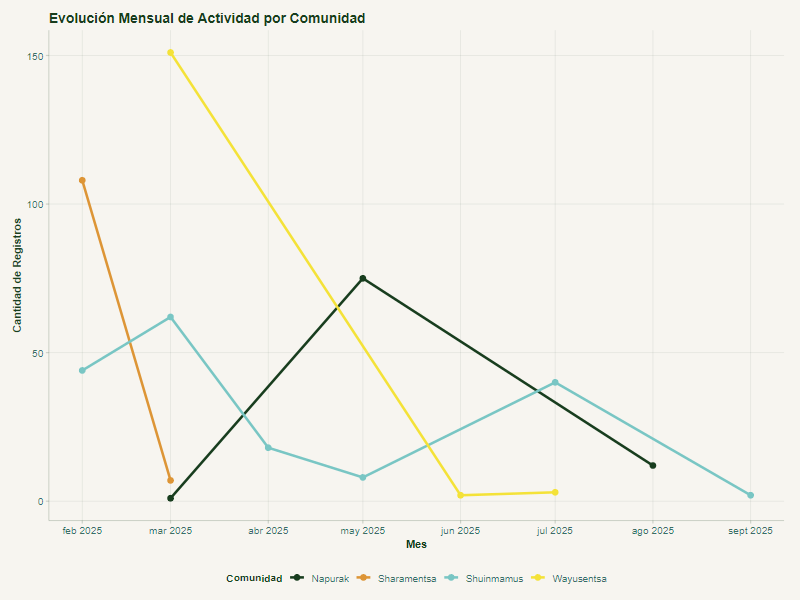

In [6]:


# 2. Procesar datos
serie_mensual <- censos_df_1 %>%
  mutate(Mes = floor_date(as.Date(Fecha), "month")) %>%
  group_by(Mes, Comunidad_x) %>%
  summarise(Total_registros = n(), .groups = "drop")

# 3. Generar la gráfica con el estilo de la marca
ggplot(serie_mensual, aes(x = Mes, y = Total_registros, color = Comunidad_x, group = Comunidad_x)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2.5) +
  
  # USA ESTA FUNCIÓN (está definida en tu script de temas)
  scale_color_pacha() + 
  
  # Ejes y Títulos
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  labs(
    title = "Evolución Mensual de Actividad por Comunidad",

    x = "Mes",
    y = "Cantidad de Registros",
    color = "Comunidad"
  ) +
  
  # EL TEMA (ajustado para evitar error de fuentes)
  theme_pachamama() +
  theme(text = element_text(family = "sans")) # Forzamos una fuente estándar si falla Raleway

In [7]:
total_comunidades <- censos_df_1 %>%
  group_by(Comunidad_x) %>%
  summarise(Total = n(), .groups = "drop") %>%
  arrange(desc(Total)) # Ordenamos de mayor a menor
total_comunidades

# A tibble: 4 × 2
  Comunidad_x Total
  <chr>       <int>
1 Shuinmamus    174
2 Wayusentsa    156
3 Sharamentsa   115
4 Napurak        88

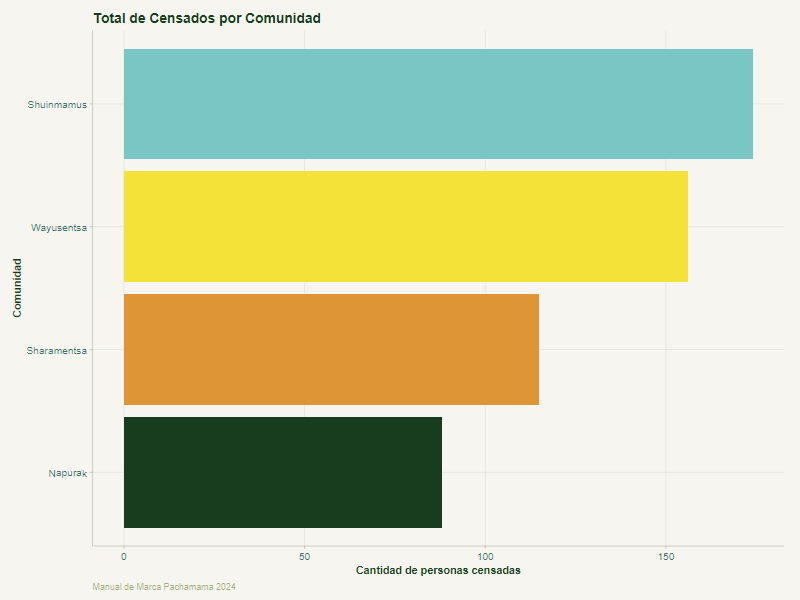

In [8]:
ggplot(total_comunidades, aes(x = reorder(Comunidad_x, Total), y = Total, fill = Comunidad_x)) +
  geom_col(show.legend = FALSE) + # Las barras ya tienen el nombre abajo, no hace falta leyenda
  coord_flip() +                 # Giramos la gráfica para que los nombres de comunidades se lean bien
  scale_fill_pacha() +           # Colores oficiales de la Fundación
  labs(
    title = "Total de Censados por Comunidad",
    x = "Comunidad",
    y = "Cantidad de personas censadas",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  theme_pachamama() +            # Tu tema personalizado
  theme(text = element_text(family = "sans")) # Evita errores si no tienes instalada la fuente Raleway

## 3.4. Enfermedades

### Total con enfermemdades

Mas del 50% de la población tiene un problema de salud

In [9]:
total_salud <- censos_df_1 %>%
  group_by(CondicionSalud) %>%
  #filter(CondicionSalud != "")%>%
  summarise(Total = n(), .groups = "drop") %>%
  arrange(desc(Total))

total_salud

# A tibble: 9 × 2
  CondicionSalud      Total
  <chr>               <int>
1 ""                    238
2 "Parasitos"           149
3 "Desnutricion"         52
4 "Otra"                 47
5 "Enferm infecciosa"    17
6 "Discap visual"        10
7 "Discap mental"         9
8 "Discap auditiva"       7
9 "Discap motriz"         4

In [10]:
data_pastel <- censos_df_1 %>%
  mutate(Estado_Salud = if_else(is.na(CondicionSalud) | CondicionSalud == "", 
                                "Sin enfermedad reportada", 
                                "Con enfermedad reportada")) %>%
  group_by(Estado_Salud) %>%
  summarise(Total = n(), .groups = "drop") %>%
  mutate(Porcentaje = Total / sum(Total) * 100,
         Etiqueta = paste0(round(Porcentaje, 1), "%")) # Creamos el texto del porcentaje
         data_pastel

# A tibble: 2 × 4
  Estado_Salud             Total Porcentaje Etiqueta
  <chr>                    <int>      <dbl> <chr>   
1 Con enfermedad reportada   295       55.3 55.3%   
2 Sin enfermedad reportada   238       44.7 44.7%   

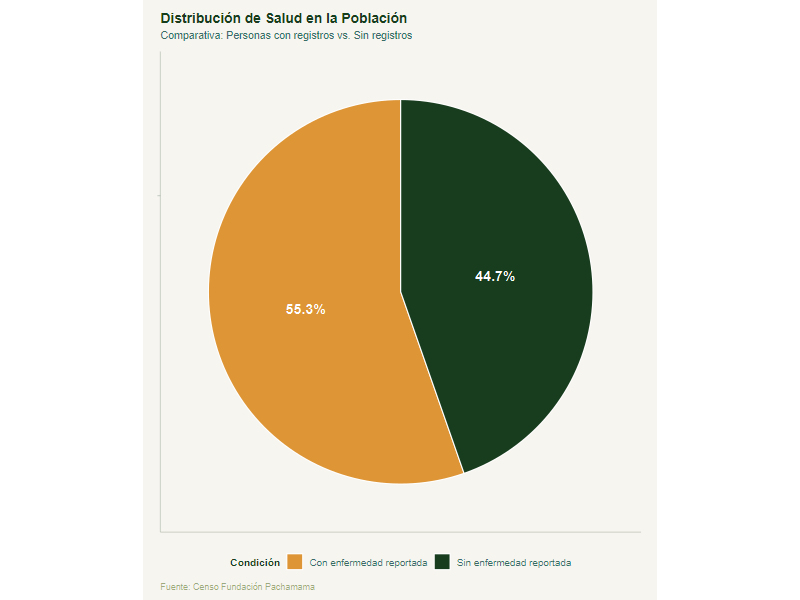

In [11]:
ggplot(data_pastel, aes(x = "", y = Total, fill = Estado_Salud)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar("y", start = 0) +
  
  # Usamos colores contrastantes de la paleta institucional
  scale_fill_manual(values = c("Con enfermedad reportada" = PAL$ave, 
                               "Sin enfermedad reportada" = PAL$hoja)) +
  
  # Añadimos los porcentajes dentro del pastel
  geom_text(aes(label = Etiqueta), 
            position = position_stack(vjust = 0.5), 
            color = "white", fontface = "bold", size = 5) +
  
  labs(
    title = "Distribución de Salud en la Población",
    subtitle = "Comparativa: Personas con registros vs. Sin registros",
    fill = "Condición",
    caption = "Fuente: Censo Fundación Pachamama"
  ) +
  
  theme_pachamama() +
  theme(
    axis.text.x = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    panel.grid.major = element_blank(), # Limpiamos el fondo para el pastel
    text = element_text(family = "sans")
  )

### Distribución de condiciónes de salud

Monitoreo enfermedades perspectiva cultural

In [12]:

# Filtrar y preparar conteo
data_enfermedades <- censos_df_1 %>%
  # Quitamos los vacíos y NAs para ver solo las condiciones
  filter(!is.na(CondicionSalud), CondicionSalud != "") %>%
  group_by(CondicionSalud) %>%
  summarise(Total = n(), .groups = "drop") %>%
  arrange(desc(Total))
data_enfermedades

# A tibble: 8 × 2
  CondicionSalud    Total
  <chr>             <int>
1 Parasitos           149
2 Desnutricion         52
3 Otra                 47
4 Enferm infecciosa    17
5 Discap visual        10
6 Discap mental         9
7 Discap auditiva       7
8 Discap motriz         4

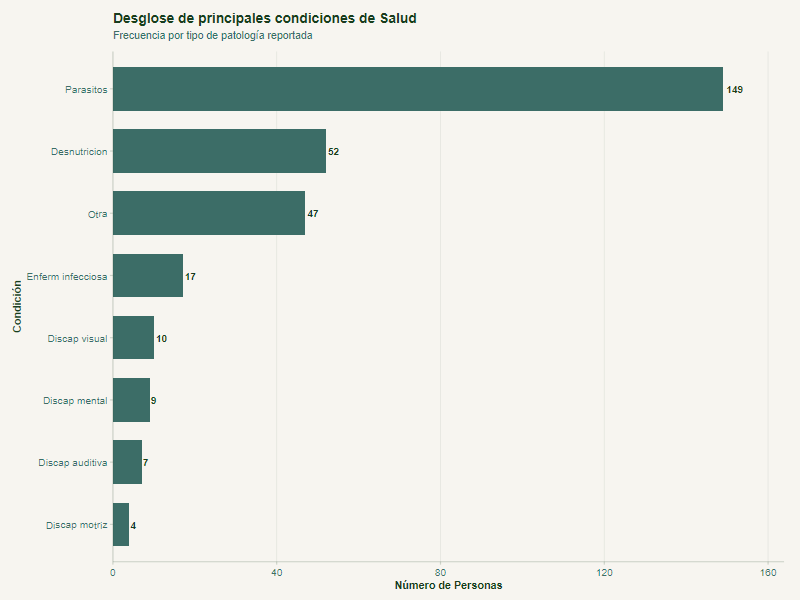

In [13]:
ggplot(data_enfermedades, aes(x = reorder(CondicionSalud, Total), y = Total)) +
  # Usamos el color 'rio' de tu lista PAL
  geom_col(fill = PAL$rio, width = 0.7) + 
  
  # Giramos para leer bien los nombres
  coord_flip() + 
  
  # Añadimos el número total al final de cada barra para mayor claridad
  geom_text(aes(label = Total), 
            hjust = -0.2, 
            color = PAL$hoja, 
            size = 3.5, 
            fontface = "bold") +
  
  labs(
    title = "Desglose de principales condiciones de Salud",
    subtitle = "Frecuencia por tipo de patología reportada",
    x = "Condición",
    y = "Número de Personas"
  ) +
  
  # Ajustamos el límite del eje Y para que el texto no se corte
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  
  theme_pachamama() +
  theme(
    panel.grid.major.y = element_blank(), # Quitamos líneas horizontales para limpiar
    text = element_text(family = "sans")
  )

## 3.5. Socio demográfica

### Género

In [14]:
censos_df_1%>%
  # Quitamos los vacíos y NAs para ver solo las condiciones
  group_by(Genero) %>%
  summarise(Total = n(), .groups = "drop") %>%
  arrange(desc(Total))

# A tibble: 3 × 2
  Genero   Total
  <chr>    <int>
1 "Hombre"   268
2 "Mujer"    264
3 ""           1

In [15]:
ratio_genero <- censos_df_1 %>%
  # eliminar vacíos y NA
  filter(!is.na(Genero), Genero != "") %>%
  
  # contar por género
  count(Genero, name = "Total") %>%
  
  # pasar a formato ancho para calcular ratio
  tidyr::pivot_wider(names_from = Genero, values_from = Total) %>%
  
  # calcular métricas
  mutate(
    ratio_H_M = Hombre / Mujer,
    hombres_por_100_mujeres = (Hombre / Mujer) * 100
  )

ratio_genero

# A tibble: 1 × 4
  Hombre Mujer ratio_H_M hombres_por_100_mujeres
   <int> <int>     <dbl>                   <dbl>
1    268   264      1.02                    102.

Ratio hombres/mujeres

In [16]:
ratio_genero_comunidad <- censos_df_1 %>%
  # eliminar vacíos y NA en género
  filter(!is.na(Genero), Genero != "") %>%
  
  # conteo por comunidad y género
  count(Comunidad_x, Genero, name = "Total") %>%
  
  # pasar a formato ancho (columnas Hombre / Mujer)
  pivot_wider(
    names_from  = Genero,
    values_from = Total,
    values_fill = 0
  ) %>%
  
  # calcular ratio
  mutate(
    ratio_H_M = Hombre / Mujer,
    hombres_por_100_mujeres = (Hombre / Mujer) * 100
  ) %>%
  
  arrange(desc(ratio_H_M))

ratio_genero_comunidad

# A tibble: 4 × 5
  Comunidad_x Hombre Mujer ratio_H_M hombres_por_100_mujeres
  <chr>        <int> <int>     <dbl>                   <dbl>
1 Sharamentsa     63    52     1.21                    121. 
2 Wayusentsa      81    75     1.08                    108  
3 Shuinmamus      85    88     0.966                    96.6
4 Napurak         39    49     0.796                    79.6

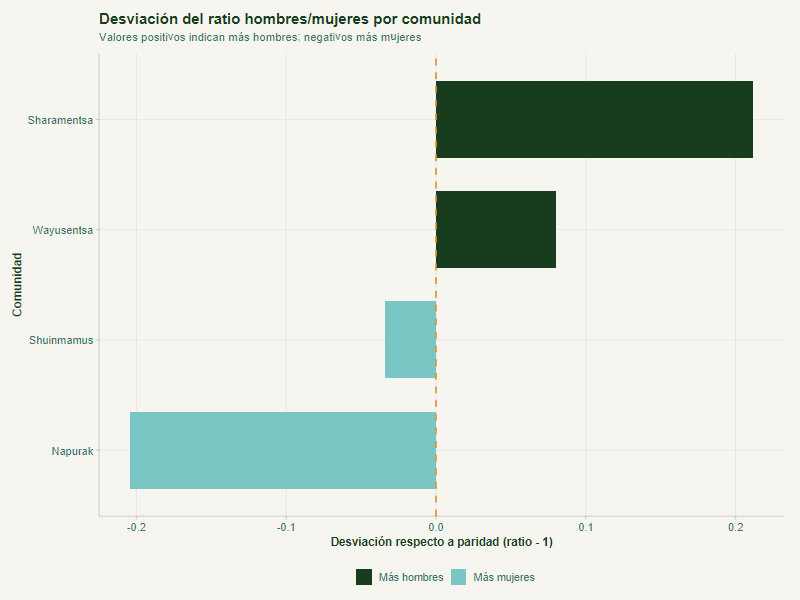

In [17]:
ratio_plot <- ratio_genero_comunidad %>%
  mutate(
    # centrar en 1 → paridad = 0
    ratio_center = ratio_H_M - 1,
    
    # dirección para color
    direccion = case_when(
      ratio_center > 0 ~ "Más hombres",
      ratio_center < 0 ~ "Más mujeres",
      TRUE ~ "Paridad"
    )
  )

ggplot(ratio_plot,
       aes(x = reorder(Comunidad_x, ratio_center),
           y = ratio_center,
           fill = direccion)) +
  
  geom_col(width = 0.7) +
  
  # línea central en paridad (0 después de centrar)
  geom_hline(yintercept = 0, linetype = "dashed",
             color = PAL$ave, linewidth = 0.8) +
  
  coord_flip() +
  
  scale_fill_manual(
    values = c(
      "Más hombres" = PAL$hoja,
      "Más mujeres" = PAL$cielo,
      "Paridad"     = PAL$arcilla
    )
  ) +
  
  labs(
    title = "Desviación del ratio hombres/mujeres por comunidad",
    subtitle = "Valores positivos indican más hombres; negativos más mujeres",
    x = "Comunidad",
    y = "Desviación respecto a paridad (ratio - 1)",
    fill = ""
  ) +
  
  theme_pachamama(base_size = 13, legend_pos = "bottom")

### Distribución de edades

Pirámide poblaciona

In [18]:

# 1. Crear rangos de edad y preparar datos
data_piramide <- censos_df_1 %>%
  filter(!is.na(Edad), !is.na(Genero)) %>%
  # Creamos grupos de edad cada 5 o 10 años
  mutate(Rango_Edad = cut(Edad, breaks = seq(0, 100, by = 5), right = FALSE)) %>%
  group_by(Rango_Edad, Genero) %>%
  summarise(Total = n(), .groups = "drop") %>%
  # Convertimos Masculino a negativo para el eje izquierdo
  mutate(Total_Grafico = if_else(Genero == "Mujer", -Total, Total))

data_piramide

# A tibble: 34 × 4
   Rango_Edad Genero Total Total_Grafico
   <fct>      <chr>  <int>         <int>
 1 [0,5)      Hombre    45            45
 2 [0,5)      Mujer     33           -33
 3 [5,10)     Hombre    48            48
 4 [5,10)     Mujer     44           -44
 5 [10,15)    Hombre    44            44
 6 [10,15)    Mujer     39           -39
 7 [15,20)    Hombre    28            28
 8 [15,20)    Mujer     27           -27
 9 [20,25)    Hombre    14            14
10 [20,25)    Mujer     29           -29
# ℹ 24 more rows
# ℹ Use `print(n = ...)` to see more rows

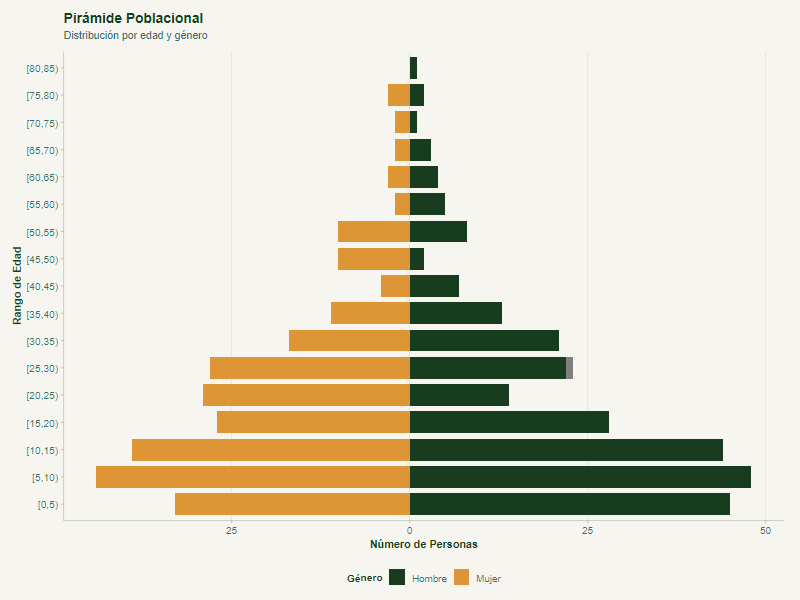

In [19]:
plot_piramide = ggplot(data_piramide, aes(x = Rango_Edad, y = Total_Grafico, fill = Genero)) +
  geom_col(width = 0.8) +
  coord_flip() +  # Volteamos la gráfica para que las edades suban
  
  # Colores institucionales
  scale_fill_manual(values = c("Mujer" = PAL$ave, "Hombre" = PAL$hoja)) +
  
  # Ajustamos el eje Y para que no muestre números negativos
  scale_y_continuous(labels = abs) + 
  
  labs(
    title = "Pirámide Poblacional",
    subtitle = "Distribución por edad y género",
    x = "Rango de Edad",
    y = "Número de Personas",
    fill = "Género"
  ) +
  
  theme_pachamama() +
  theme(
    panel.grid.major.y = element_blank(),
    text = element_text(family = "sans")
  )
  plot_piramide

In [20]:
# Convertimos la gráfica estática en interactiva
piramide_interactiva <- ggplotly(plot_piramide, tooltip = "text") %>%
  layout(
    # Ajustamos el título para que no se encime
    title = list(text = paste0('<b>Pirámide Poblacional</b>',
                               '<br><sup>Distribución por edad y género</sup>')),
    # Mantenemos el estilo del fondo de la Fundación
    paper_bgcolor = PAL$fondo,
    plot_bgcolor = PAL$fondo
  )

# Mostrar la gráfica
#piramide_interactiva

Edades vulnerables basado en la CEPAL

In [21]:
tabla_vulnerables <- censos_df_1 %>%
  mutate(
    Edad = as.numeric(Edad),
    grupo_vulnerable = case_when(
      Edad >= 0  & Edad <= 5  ~ "Niñez temprana (0-5)",
      Edad > 65               ~ "Adultos mayores (>65)",
      TRUE                    ~ NA_character_
    )
  ) %>%
  filter(!is.na(grupo_vulnerable)) %>%
  group_by(grupo_vulnerable) %>%
  summarise(
    Total = n(),
    Edad_min = min(Edad, na.rm = TRUE),
    Edad_max = max(Edad, na.rm = TRUE),
    Edad_media = mean(Edad, na.rm = TRUE),
    .groups = "drop"
  )

tabla_vulnerables

# A tibble: 2 × 5
  grupo_vulnerable      Total Edad_min Edad_max Edad_media
  <chr>                 <int>    <dbl>    <dbl>      <dbl>
1 Adultos mayores (>65)    12       67       82      73.8 
2 Niñez temprana (0-5)    100        1        5       2.94

In [22]:
# ============================================================
# Tabla resumen de grupos vulnerables por comunidad
# ============================================================

tabla_vulnerables_comunidad <- censos_df_1 %>%
  mutate(
    Edad = as.numeric(Edad),
    grupo_vulnerable = case_when(
      Edad >= 0  & Edad <= 5  ~ "Niñez temprana (0-5)",
      Edad > 65               ~ "Adultos mayores (>65)",
      TRUE                    ~ NA_character_
    )
  ) %>%
  filter(!is.na(grupo_vulnerable)) %>%
  group_by(Comunidad_x, grupo_vulnerable) %>%
  summarise(
    Total = n(),
    .groups = "drop"
  ) %>%
  arrange(Comunidad_x, grupo_vulnerable)

tabla_vulnerables_comunidad

# A tibble: 8 × 3
  Comunidad_x grupo_vulnerable      Total
  <chr>       <chr>                 <int>
1 Napurak     Adultos mayores (>65)     2
2 Napurak     Niñez temprana (0-5)     14
3 Sharamentsa Adultos mayores (>65)     3
4 Sharamentsa Niñez temprana (0-5)     24
5 Shuinmamus  Adultos mayores (>65)     4
6 Shuinmamus  Niñez temprana (0-5)     37
7 Wayusentsa  Adultos mayores (>65)     3
8 Wayusentsa  Niñez temprana (0-5)     25

In [23]:
tabla_vulnerables_pct <- censos_df_1 %>%
  mutate(
    Edad = as.numeric(Edad),
    grupo_vulnerable = case_when(
      Edad >= 0  & Edad <= 5  ~ "Niñez temprana (0-5)",
      Edad > 65               ~ "Adultos mayores (>65)",
      TRUE                    ~ "No vulnerable"
    )
  ) %>%
  group_by(grupo_vulnerable) %>%
  summarise(Total = n(), .groups = "drop") %>%
  mutate(
    Porcentaje = round(100 * Total / sum(Total), 2)
  )

tabla_vulnerables_pct

# A tibble: 3 × 3
  grupo_vulnerable      Total Porcentaje
  <chr>                 <int>      <dbl>
1 Adultos mayores (>65)    12       2.25
2 Niñez temprana (0-5)    100      18.8 
3 No vulnerable           421      79.0 